In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import os


In [2]:
# ✅ Step 2: Dataset path
data_dir = r'C:\Users\Lenovo\OneDrive\Desktop\ytsignproject\ytsignproject\ASLdataset'  # <-- change path if needed



In [3]:
# 📊 Step 3: Data Preprocessing + Auto Train-Val Split
img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,     # 80% train, 20% validation
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 3746 images belonging to 26 classes.
Found 935 images belonging to 26 classes.


In [4]:
# 📈 Step 4: Model Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 🧮 Step 5: Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)


C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 89s 721ms/step - accuracy: 0.0736 - loss: 3.2402 - val_accuracy: 0.3551 - val_loss: 2.1769
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 79s 664ms/step - accuracy: 0.3655 - loss: 2.0267 - val_accuracy: 0.6738 - val_loss: 1.0972
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 79s 670ms/step - accuracy: 0.6327 - loss: 1.1557 - val_accuracy: 0.8021 - val_loss: 0.6701
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 625ms/step - accuracy: 0.7232 - loss: 0.8374 - val_accuracy: 0.8684 - val_loss: 0.4479
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 630ms/step - accuracy: 0.7824 - loss: 0.6328 - val_accuracy: 0.9037 - val_loss: 0.3421
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 641ms/step - accuracy: 0.8336 - loss: 0.4952 - val_accuracy: 0.8995 - val_loss: 0.3240
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 74s 629ms/step - accuracy: 0.8406 - loss: 0.4868 - val_accuracy: 0.9583 - val_loss: 0.1672
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 73s 621ms/step - accuracy: 0.8764 - loss: 0

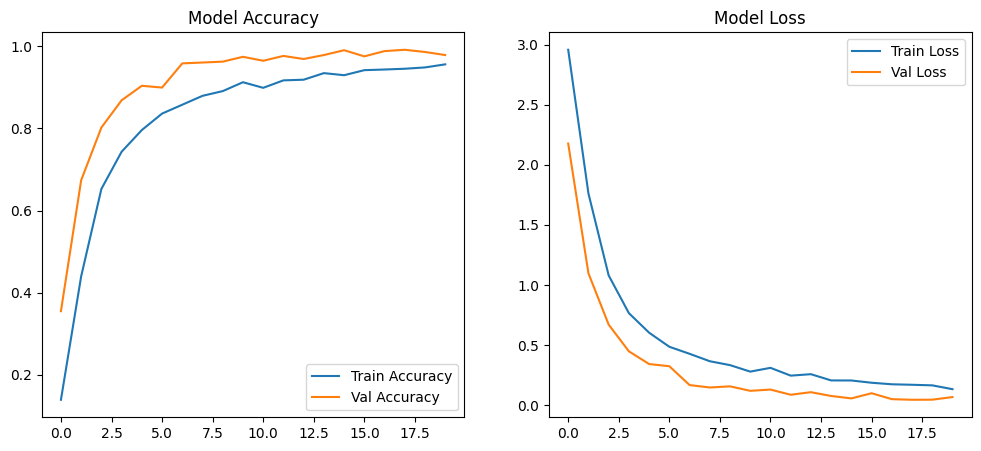

In [6]:
# 🧠 Step 6: Plot Accuracy & Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.show()



30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step


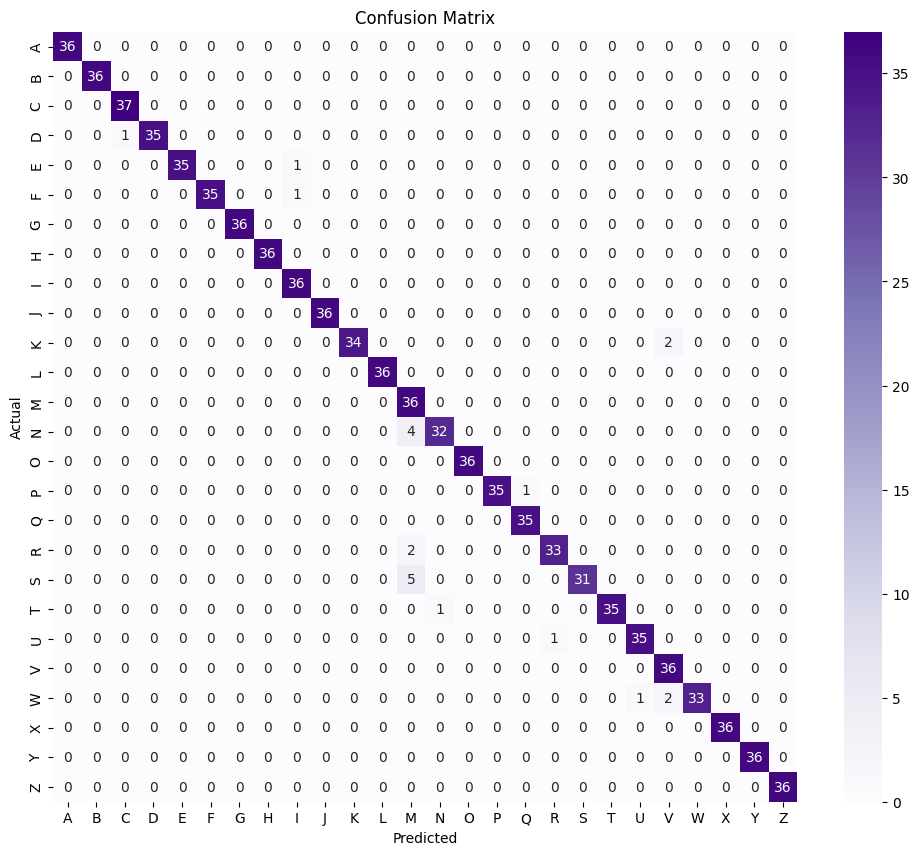

In [7]:
# 📊 Step 7: Confusion Matrix
y_true = val_data.classes
y_pred = np.argmax(model.predict(val_data), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(train_data.class_indices.keys()),
            yticklabels=list(train_data.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [8]:
# 📋 Step 8: Classification Report
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))



              precision    recall  f1-score   support

           A       1.00      1.00      1.00        36
           B       1.00      1.00      1.00        36
           C       0.97      1.00      0.99        37
           D       1.00      0.97      0.99        36
           E       1.00      0.97      0.99        36
           F       1.00      0.97      0.99        36
           G       1.00      1.00      1.00        36
           H       1.00      1.00      1.00        36
           I       0.95      1.00      0.97        36
           J       1.00      1.00      1.00        36
           K       1.00      0.94      0.97        36
           L       1.00      1.00      1.00        36
           M       0.77      1.00      0.87        36
           N       0.97      0.89      0.93        36
           O       1.00      1.00      1.00        36
           P       1.00      0.97      0.99        36
           Q       0.97      1.00      0.99        35
           R       0.97    

In [9]:
# 💾 Step 9: Save model
model.save("sign_language_AtoZ_model.h5")


In [10]:
# ✅ Step 10: Final Accuracy
final_acc = history.history['val_accuracy'][-1] * 100
print(f"\nFinal Validation Accuracy: {final_acc:.2f}%")


Final Validation Accuracy: 97.86%
